# UMAP / t-SNE embedding visualisation

Run cells **1 → 4** once (embedding + reduction is expensive).  
Re-run **cell 5** freely to iterate on plot styling.

## 1 · Config

In [89]:
from pathlib import Path

# ── paths ──────────────────────────────────────────────────────────────────────
MODEL_PATH   = Path("/home/libe2152/outputs/explainable-earth-embeddings/modified-git-10M/txt-open_clip__loc-satclip__tproj-linear__lproj-none__tft-all__lft-only_proj__loss-clip__lr-0.0001__sub-1000000/best.pt")   
CONCEPT_SET  = Path("/home/libe2152/projects/explainable-earth-embeddings/data/git-10m/concept_dictionaries/concept_dictionary_n500000.json")    
OUTPUT_DIR   = Path("plots") / CONCEPT_SET.stem      # or set an explicit path

# ── sampling ───────────────────────────────────────────────────────────────────
NUM_SAMPLES            = None  # None → use all
STRATIFY_BY_CONTINENT  = True

# ── column names in the location dataframe ─────────────────────────────────────
LAT_COL = "lat"
LON_COL = "lon"

# ── optional: explicit locations parquet/csv (None → use path from checkpoint) ─
LOCATIONS_PATH = Path("/home/libe2152/data/s2-100k/index.csv")  # e.g. Path("../data/locations/")

## 2 · Imports & model/data loading

In [90]:
import argparse, json, sys
import numpy as np
import pandas as pd
import torch

# notebook lives in eval_results/ alongside plot.py
_here = Path.cwd()
sys.path.insert(0, str(_here))        # for plot.py
sys.path.insert(0, str(_here.parent)) # for models/

from plot import (
    load_model, embed_locations, embed_concepts,
    center_renorm, get_continents,
    CONTINENT_PALETTE, CONCEPT_COLOR
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

device: cuda


In [91]:
# Load locations dataframe
if LOCATIONS_PATH is not None:
    loc_p = Path(LOCATIONS_PATH)
    files = sorted(loc_p.glob("*.parquet")) or sorted(loc_p.glob("*.csv")) if loc_p.is_dir() else [loc_p]
    dfs = [pd.read_parquet(f) if f.suffix == ".parquet" else pd.read_csv(f) for f in files]
else:
    ckpt_dataset = argparse.Namespace(
        **torch.load(MODEL_PATH, map_location="cpu", weights_only=False)["args"]
    ).dataset_path
    dfs = [pd.read_parquet(p) for p in sorted(Path(ckpt_dataset).glob("*.parquet"))]
df = pd.concat(dfs, ignore_index=True)

# Optional stratified sampling
if NUM_SAMPLES and len(df) > NUM_SAMPLES:
    if STRATIFY_BY_CONTINENT:
        cont_labels_full, _ = get_continents(df)
        df["_continent"] = cont_labels_full
        n_per = max(1, NUM_SAMPLES // df["_continent"].nunique())
        df = df.groupby("_continent", group_keys=False).apply(
            lambda g: g.sample(min(len(g), n_per), random_state=0)
        ).reset_index(drop=True)
    df = (df.sample(frac=1, random_state=0)
            .head(NUM_SAMPLES)
            .drop(columns="_continent", errors="ignore")
            .reset_index(drop=True))

print(f"Locations: {len(df):,}")

# Load model
loc_precomputed = "location_embedding" in df.columns
model, model_args = load_model(MODEL_PATH, device, loc_precomputed=loc_precomputed)
print("Model args:", vars(model_args))

Locations: 100,000


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] CLIPTextModelWithProjection LOAD REPORT from: openai/clip-vit-large-patch14
Key                                                            | Status     |  | 
---------------------------------------------------------------+------------+--+-
vision_model.encoder.layers.{0...23}.self_attn.v_proj.weight   | UNEXPECTED |  | 
vision_model.encoder.layers.{0...23}.layer_norm1.bias          | UNEXPECTED |  | 
vision_model.encoder.layers.{0...23}.mlp.fc2.bias              | UNEXPECTED |  | 
logit_scale                                                    | UNEXPECTED |  | 
vision_model.encoder.layers.{0...23}.self_attn.q_proj.bias     | UNEXPECTED |  | 
vision_model.encoder.layers.{0...23}.self_attn.k_proj.bias     | UNEXPECTED |  | 
vision_model.encoder.layers.{0...23}.self_attn.out_proj.bias   | UNEXPECTED |  | 
vision_model.encoder.layers.{0...23}.self_attn.k_proj.weight   | UNEXPECTED |  | 
vision_model.encoder.layers.{0...23}.layer_norm1.weight        | UNEXPECTED |  | 
vision_

using pretrained moco vit16
Model args: {'dataset_path': '/home/libe2152/data/modified-git-10M/satclip/open_clip/', 'train_subsample_size': 1000000, 'val_subsample_size': 250000, 'precomputed_text_embeddings': False, 'precomputed_location_embeddings': True, 'text_encoder': 'open_clip', 'location_encoder': 'satclip', 'text_finetune_mode': 'all', 'loc_finetune_mode': 'only_proj', 'text_projection': 'linear', 'text_proj_hidden_layers': 1, 'text_proj_hidden_features': 512, 'location_projection': 'none', 'loc_proj_hidden_layers': 1, 'loc_proj_hidden_features': 512, 'shared_dim': 256, 'train_loss': 'clip', 'lambda_alignment': 1.0, 'sigma': 1.0, 'logit_scale_temp': 0.07, 'num_epochs': 500, 'patience': 20, 'batch_size': 4096, 'lr': 0.0001, 'weight_decay': 0.01, 'text_nonlinearity': 'relu', 'loc_nonlinearity': 'sine', 'num_workers': 4, 'seed': 42, 'device': 'cuda', 'model_save_path': None, 'resume_from': None, 'wandb_entity': 'boulder-rolf-lab', 'wandb_project': 'explainable-earth-embeddings', 

## 3 · Compute embeddings  *(run once)*

In [92]:
loc_emb = embed_locations(model, df, device, lat_col=LAT_COL, lon_col=LON_COL)

concepts_raw = json.loads(Path(CONCEPT_SET).read_text())
concepts = list(concepts_raw.keys()) if isinstance(concepts_raw, dict) else [str(c) for c in concepts_raw]
concept_emb = embed_concepts(model, [c for c in concepts])

loc_mc  = center_renorm(loc_emb,     center=True)
con_mc  = center_renorm(concept_emb, center=True)
cont_labels, _ = get_continents(df)

print(f"loc_mc: {loc_mc.shape}  |  con_mc: {con_mc.shape}  |  concepts: {len(concepts)}")

Concept emb: 100%|██████████| 1/1 [00:00<00:00, 53.17it/s]


loc_mc: torch.Size([100000, 256])  |  con_mc: torch.Size([1021, 256])  |  concepts: 1021


## 4 · Dimensionality reduction  *(run once)*

In [ ]:
from plot import umap_reduce, tsne_reduce

combined = torch.cat([loc_mc, con_mc]).numpy()
n = len(loc_mc)

# umap_reduce: n_neighbors=15, min_dist=0.1, metric="cosine"
# tsne_reduce: perplexity=30, learning_rate=200, max_iter=1000, init="pca"
Y_umap = umap_reduce(combined, n_components=2, n_neighbors=30, min_dist=0.05, metric="cosine", pca_dim=50)
#Y_tsne = tsne_reduce(combined, n_components=2)

Y_umap_loc, Y_umap_con = Y_umap[:n], Y_umap[n:]
#Y_tsne_loc, Y_tsne_con = Y_tsne[:n], Y_tsne[n:]
print("Reductions done.")

## 5 · Plot  *(re-run freely)*

In [ ]:
SAVE=False

In [ ]:
_RCPARAMS = {
    "font.family":        "serif",
    "font.serif":         ["Linux Libertine O", "Libertinus Serif", "Times New Roman",
                           "Nimbus Roman", "DejaVu Serif"],
    "mathtext.fontset":   "stix",
    "pdf.fonttype":       42,
    "ps.fonttype":        42,
    "axes.titlesize":     20,
    "axes.labelsize":     20,
    "font.size":          24,
    "legend.fontsize":    20,
    "xtick.labelsize":    10,
    "ytick.labelsize":    10,
    "axes.linewidth":     0.8,
    "figure.dpi":         150,
    "savefig.dpi":        400,
    "savefig.bbox":       "tight",
    "savefig.pad_inches": 0.04,
    "figure.facecolor":   "white",
    "axes.facecolor":     "white",
}

In [ ]:
CONTINENT_PALETTE = {
    "Africa":        "#C2B280",  # sand / warm earth (muted beige)
    "Asia":          "#4C78A8",  # soft blue
    "Europe":        "#59A14F",  # muted green
    "North America": "#2F5597",  # deep navy blue
    "South America": "#7B6AAE",  # muted purple (desaturated lavender)
    "Oceania":       "#76B7B2",  # soft teal
    "Antarctica":    "#B0B0B0",  # neutral ice gray
}
_KNOWN_CONTINENTS = frozenset(CONTINENT_PALETTE) - {"Unknown"}
CONCEPT_COLOR = "#A60000"

In [ ]:
import matplotlib
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from plot import _with_alpha

def make_figure(Y_loc, Y_con, cont_labels, method):
    matplotlib.rcParams.update(_RCPARAMS)

    fig, ax = plt.subplots(figsize=(10, 7), dpi=300)
    fig.patch.set_facecolor("white")
    ax.set_facecolor("white")

    cont_labels = np.array(cont_labels)

    # ── filter Unknown correctly (MUST apply to both) ────────────────────────
    mask = cont_labels != "Unknown"

    cont_labels = cont_labels[mask]
    Y_loc = Y_loc[mask]

    # ── Pass 1: locations (triangles, cool colors) ──────────────────────────
    for cont in sorted(set(cont_labels)):
        m = cont_labels == cont
        c = CONTINENT_PALETTE[cont]

        ax.scatter(
            Y_loc[m, 0], Y_loc[m, 1],
            s=55,
            marker="^",
            rasterized=True,
            facecolors=_with_alpha(c, 0.6),
            edgecolors=c,
            linewidths=0.6,
        )

    # ── Pass 2: concepts (circles, warm color) ──────────────────────────────
    ax.scatter(
        Y_con[:, 0], Y_con[:, 1],
        s=90,
        marker="o",
        zorder=5,
        facecolors=_with_alpha(CONCEPT_COLOR, 0.2),
        edgecolors=CONCEPT_COLOR,
        linewidths=0.1,
    )

    # ── styling ─────────────────────────────────────────────────────────────
    ax.set_xlabel(f"{method} 1", labelpad=6)
    ax.set_ylabel(f"{method} 2", labelpad=6)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.grid(False)

    for side in ["top", "right", "left", "bottom"]:
        ax.spines[side].set_visible(False)

    # ── limits ──────────────────────────────────────────────────────────────
    all_x = np.concatenate([Y_loc[:, 0], Y_con[:, 0]])
    all_y = np.concatenate([Y_loc[:, 1], Y_con[:, 1]])

    xr = all_x.max() - all_x.min()
    yr = all_y.max() - all_y.min()

    ax.set_xlim(all_x.min() - 0.04 * xr, all_x.max() + 0.04 * xr)
    ax.set_ylim(all_y.min() - 0.04 * yr, all_y.max() + 0.04 * yr)

    # ── legend ──────────────────────────────────────────────────────────────
    present_conts = sorted(set(cont_labels))

    cont_handles = [
        Line2D(
            [0], [0],
            marker="^",
            linestyle="None",
            markersize=8,
            markerfacecolor=_with_alpha(CONTINENT_PALETTE[c], 0.6),
            markeredgecolor=CONTINENT_PALETTE[c],
            markeredgewidth=0.6,
            label=c,
        )
        for c in present_conts
    ]

    type_handles = [
        Line2D(
            [0], [0],
            marker="^",
            linestyle="None",
            markersize=9,
            markerfacecolor=_with_alpha("#888888", 0.5),
            markeredgecolor="#888888",
            markeredgewidth=0.6,
            label="Location",
        ),
        Line2D(
            [0], [0],
            marker="o",
            linestyle="None",
            markersize=8,
            markerfacecolor=_with_alpha(CONCEPT_COLOR, 0.7),
            markeredgecolor=CONCEPT_COLOR,
            markeredgewidth=0.8,
            label="Concept",
        ),
    ]

    cont_ncol = 4 if len(present_conts) <= 8 else 3

    leg1 = fig.legend(
        handles=cont_handles,
        loc="lower center",
        bbox_to_anchor=(0.5, 0.07),
        ncol=cont_ncol,
        frameon=False,
        columnspacing=1.2,
        handletextpad=0.4,
    )
    fig.add_artist(leg1)

    fig.legend(
        handles=type_handles,
        loc="lower center",
        bbox_to_anchor=(0.5, 0.02),
        ncol=2,
        frameon=False,
        columnspacing=1.6,
        handletextpad=0.5,
    )

    fig.subplots_adjust(bottom=0.22)
    return fig

Saved: plots/geoyfcc_concept_set/umap_mean_centered.png


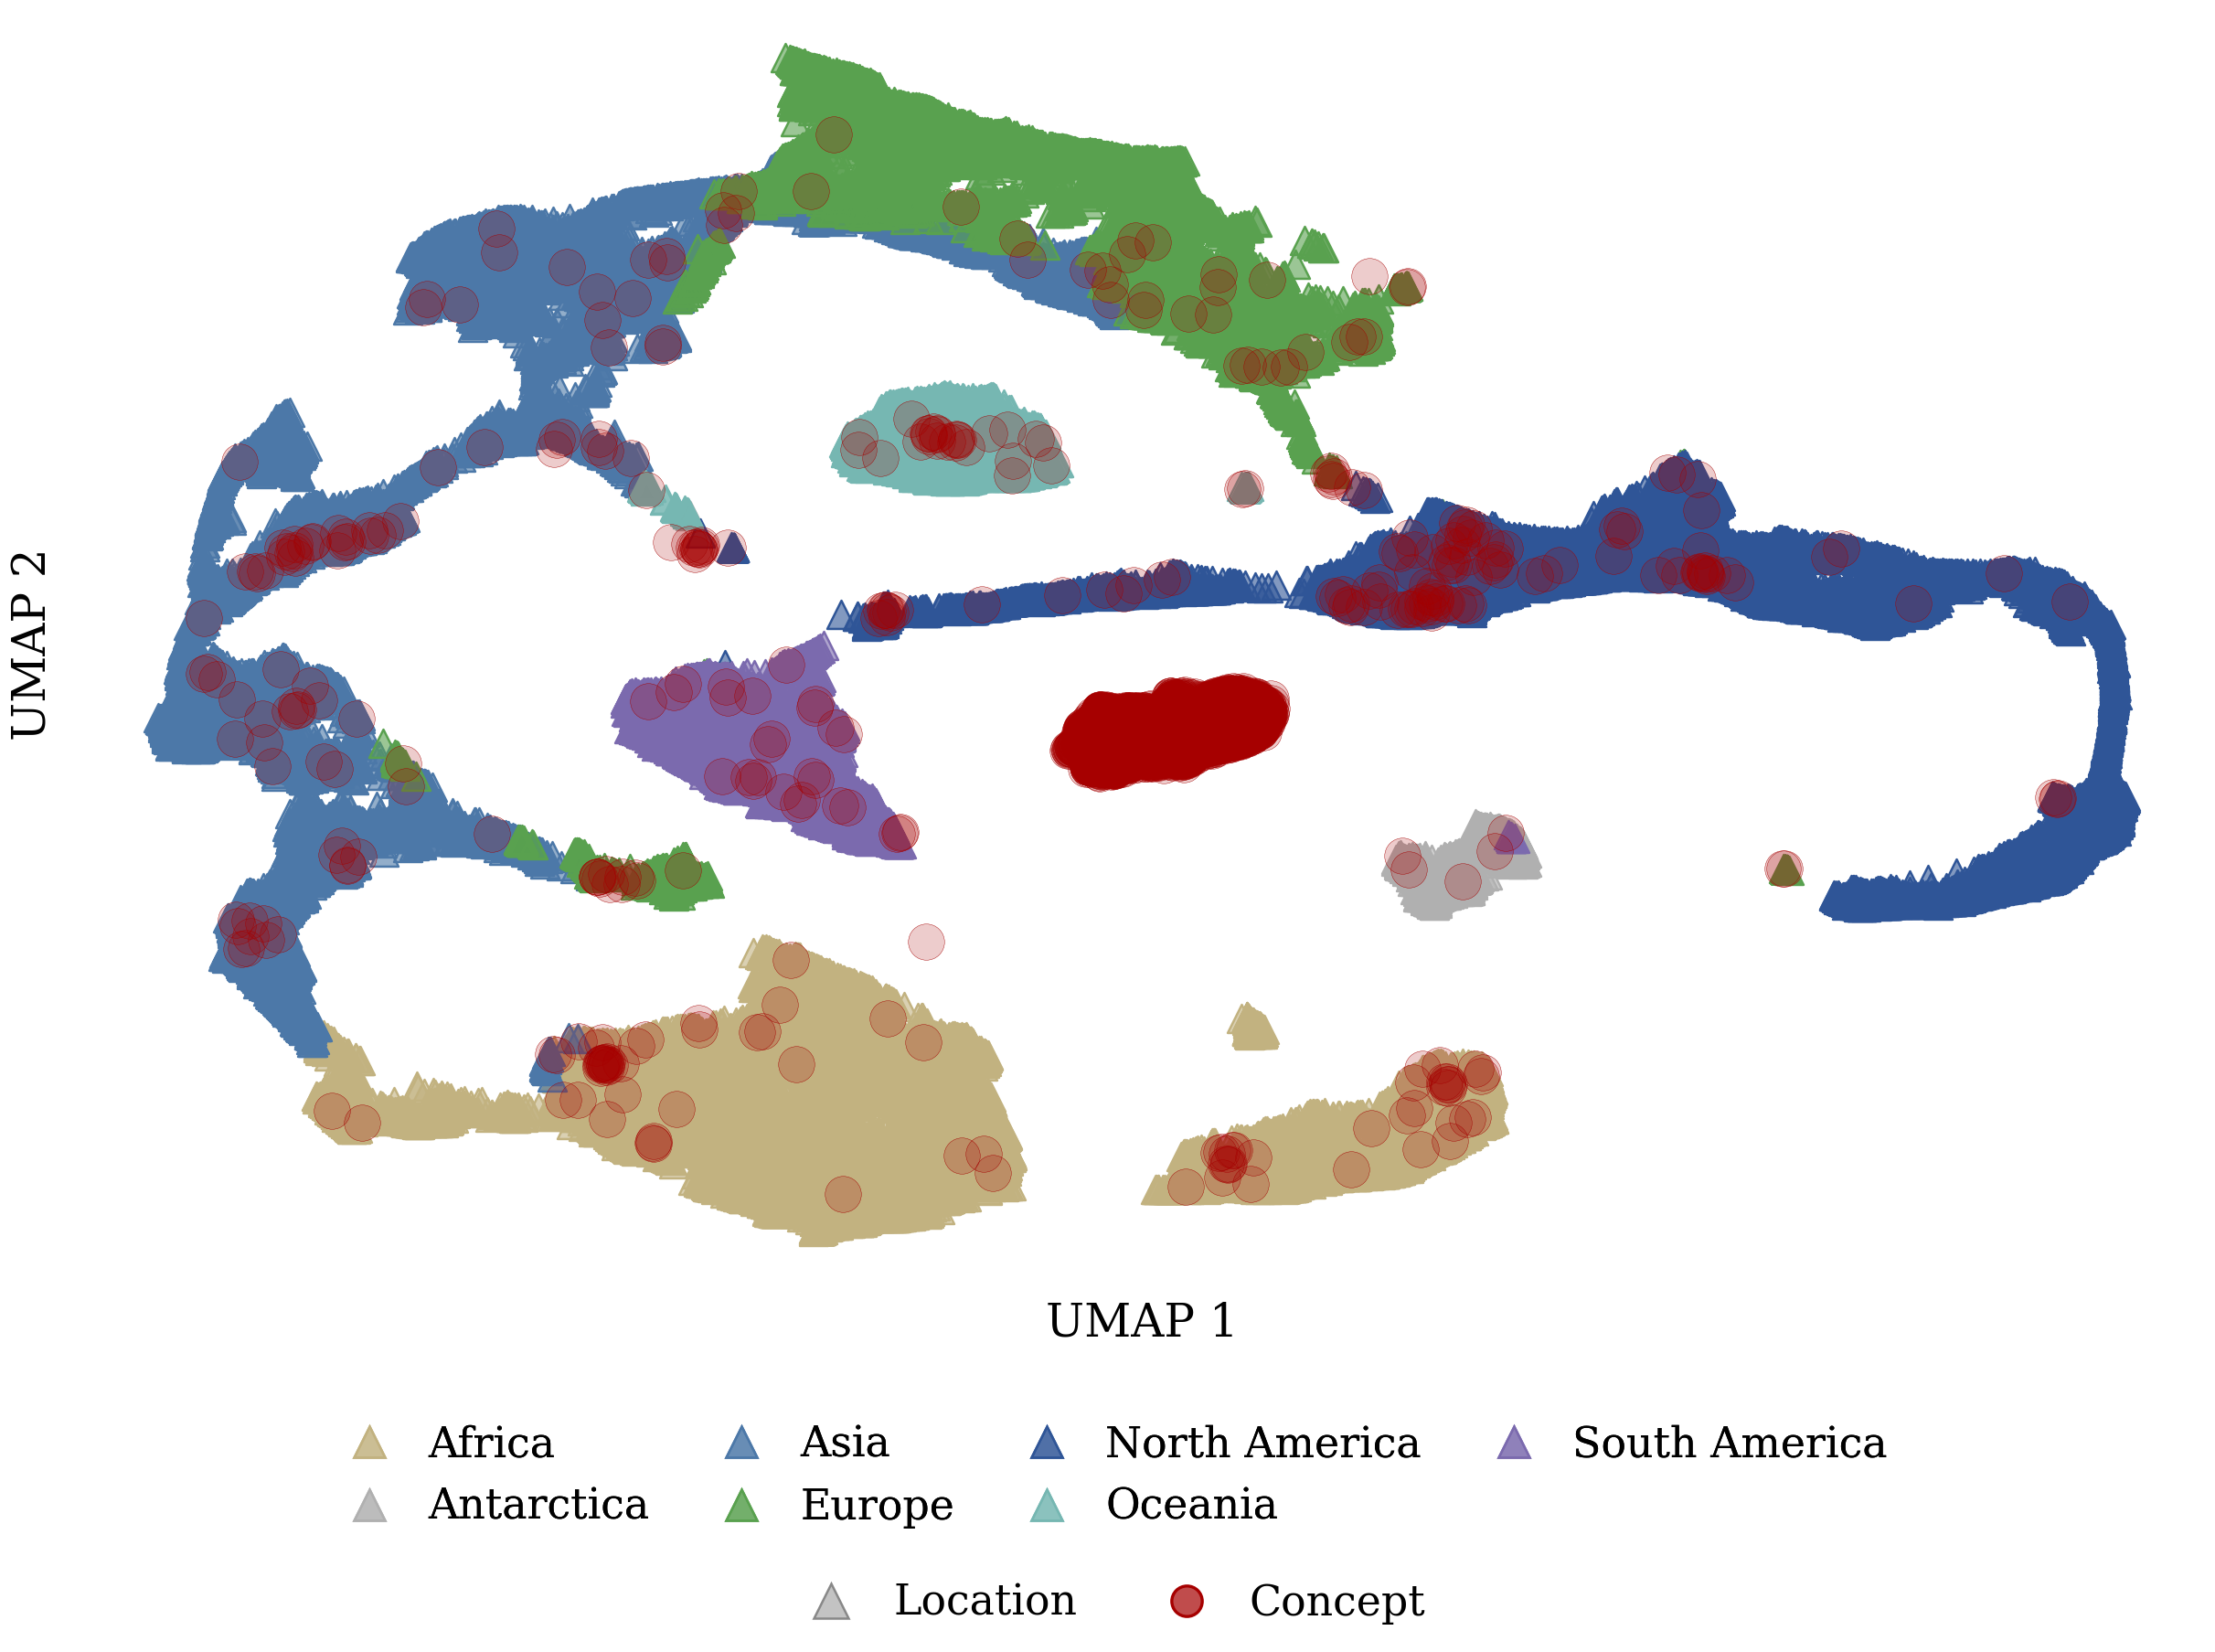

In [ ]:
# ── run block ───────────────────────────────────────────────────────────────
for Y_loc, Y_con, method, stem in [
    (Y_umap_loc, Y_umap_con, "UMAP", "umap_mean_centered"),
]:
    fig = make_figure(Y_loc, Y_con, cont_labels, method)

    if SAVE:
        out = OUTPUT_DIR / f"{stem}.png"
        out.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(out, dpi=300, bbox_inches="tight", facecolor="white")
        print(f"Saved: {out}")

    plt.show()